## A Case Scenario as a Data Scientist analyzing the dataset of a Pizza Company

#### Importing the needed library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing all datasets

In [2]:
order_details = pd.read_csv(r"C:\Users\HP\Documents\Data journey\TECH CRUSH\Datasets\Pizza-Place-Sales\pizza_sales\order_details.csv")

order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [3]:
orders = pd.read_csv(r"C:\Users\HP\Documents\Data journey\TECH CRUSH\Datasets\Pizza-Place-Sales\pizza_sales\orders.csv")

orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [4]:
pizza_types = pd.read_csv(r"C:\Users\HP\Documents\Data journey\TECH CRUSH\Datasets\Pizza-Place-Sales\pizza_sales\pizza_types.csv",
                         encoding='utf-8', encoding_errors='ignore')

pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [5]:
pizzas = pd.read_csv(r"C:\Users\HP\Documents\Data journey\TECH CRUSH\Datasets\Pizza-Place-Sales\pizza_sales\pizzas.csv")

pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


#### Joining the datasets into 1 dataframe

In [6]:
order_details.shape, orders.shape

((48620, 4), (21350, 3))

In [7]:
pizza_types.shape, pizzas.shape

((32, 4), (96, 4))

In [8]:
orders_data = pd.merge(order_details, orders, on = 'order_id', how='outer')

orders_data

,order_details_id,order_id,pizza_id,quantity,date,time
0,1,1,hawaiian_m,1,2015-01-01,11:38:36
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40
2,3,2,five_cheese_l,1,2015-01-01,11:57:40
3,4,2,ital_supr_l,1,2015-01-01,11:57:40
4,5,2,mexicana_m,1,2015-01-01,11:57:40
...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54


In [9]:
pizza_data = pd.merge(pizza_types, pizzas, how='inner', on= 'pizza_type_id')

pizza_data

,pizza_type_id,name,category,ingredients,pizza_id,size,price
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",bbq_ckn_s,S,12.75
1,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",bbq_ckn_m,M,16.75
2,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",bbq_ckn_l,L,20.75
3,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",cali_ckn_s,S,12.75
4,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",cali_ckn_m,M,16.75
...,...,...,...,...,...,...,...
91,spinach_fet,The Spinach and Feta Pizza,Veggie,"Spinach, Mushrooms, Red Onions, Feta Cheese, G...",spinach_fet_m,M,16.00
92,spinach_fet,The Spinach and Feta Pizza,Veggie,"Spinach, Mushrooms, Red Onions, Feta Cheese, G...",spinach_fet_l,L,20.25
93,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",veggie_veg_s,S,12.00
94,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",veggie_veg_m,M,16.00


In [10]:
data = pd.merge(orders_data, pizza_data, how = 'inner', on='pizza_id')

data.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,name,category,ingredients,size,price
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",L,20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",M,16.00


In [11]:
df = data.copy()

#### Knowing our final dataframe

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   name              48620 non-null  object 
 8   category          48620 non-null  object 
 9   ingredients       48620 non-null  object 
 10  size              48620 non-null  object 
 11  price             48620 non-null  float64
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [13]:
#joining the date and time column to become one column

df['date_time'] = df['date'] + ' ' + df['time']

In [14]:
#converting to a datetime datatype
df['date_time'] = pd.to_datetime(df['date_time'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  object        
 5   time              48620 non-null  object        
 6   pizza_type_id     48620 non-null  object        
 7   name              48620 non-null  object        
 8   category          48620 non-null  object        
 9   ingredients       48620 non-null  object        
 10  size              48620 non-null  object        
 11  price             48620 non-null  float64       
 12  date_time         48620 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(8)
memory usage: 4.8+ MB


In [16]:
#dropping the date and time column as they are now one column
df.drop(columns=['date', 'time'], inplace=True)
df.head()

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price,date_time
0,1,1,hawaiian_m,1,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25,2015-01-01 11:38:36
1,2,2,classic_dlx_m,1,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00,2015-01-01 11:57:40
2,3,2,five_cheese_l,1,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50,2015-01-01 11:57:40
3,4,2,ital_supr_l,1,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",L,20.75,2015-01-01 11:57:40
4,5,2,mexicana_m,1,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",M,16.00,2015-01-01 11:57:40


In [17]:
df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'pizza_type_id',
       'name', 'category', 'ingredients', 'size', 'price', 'date_time'],
      dtype='object')

In [18]:
#popping the date_time column to move it closer
col = df.pop('date_time')
col

0       2015-01-01 11:38:36
1       2015-01-01 11:57:40
2       2015-01-01 11:57:40
3       2015-01-01 11:57:40
4       2015-01-01 11:57:40
                ...        
48615   2015-12-31 21:23:10
48616   2015-12-31 21:23:10
48617   2015-12-31 21:23:10
48618   2015-12-31 22:09:54
48619   2015-12-31 23:02:05
Name: date_time, Length: 48620, dtype: datetime64[ns]

In [19]:
#inserting the popped column into the 4th index
df.insert(4, 'date_time', col)

In [20]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date_time,pizza_type_id,name,category,ingredients,size,price
0,1,1,hawaiian_m,1,2015-01-01 11:38:36,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25
1,2,2,classic_dlx_m,1,2015-01-01 11:57:40,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00
2,3,2,five_cheese_l,1,2015-01-01 11:57:40,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50
3,4,2,ital_supr_l,1,2015-01-01 11:57:40,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",L,20.75
4,5,2,mexicana_m,1,2015-01-01 11:57:40,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",M,16.00


### EDA

##### Total Revenue/Sales

In [22]:
#first we'll create a sales/revenue column using the quantity and price columns

df['sales'] = df['quantity'] * df['price']

df.head()

,order_details_id,order_id,pizza_id,quantity,date_time,pizza_type_id,name,category,ingredients,size,price,sales
0,1,1,hawaiian_m,1,2015-01-01 11:38:36,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25,13.25
1,2,2,classic_dlx_m,1,2015-01-01 11:57:40,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00,16.00
2,3,2,five_cheese_l,1,2015-01-01 11:57:40,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50,18.50
3,4,2,ital_supr_l,1,2015-01-01 11:57:40,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",L,20.75,20.75
4,5,2,mexicana_m,1,2015-01-01 11:57:40,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",M,16.00,16.00


In [25]:
#Total Revenue

total_rev = df['sales'].sum()

print(f'Total Revenue made at Pizza Place is {total_rev}')

Total Revenue made at Pizza Place is 817860.05


#### Total Quantity Sold

In [26]:
total_qty = df['quantity'].sum()

print(f'Total Quantity of pizza sold at Pizza Place is {total_qty}')

Total Quantity of pizza sold at Pizza Place is 49574


#### Total Orders

In [87]:
orders = df['quantity'].sum()

print(f'Total Orders of pizza at Pizza Place is {orders}')

Total Orders of pizza at Pizza Place is 49574


#### Total Number of Pizza types

In [28]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date_time,pizza_type_id,name,category,ingredients,size,price,sales
0,1,1,hawaiian_m,1,2015-01-01 11:38:36,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25,13.25
1,2,2,classic_dlx_m,1,2015-01-01 11:57:40,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00,16.00
2,3,2,five_cheese_l,1,2015-01-01 11:57:40,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50,18.50
3,4,2,ital_supr_l,1,2015-01-01 11:57:40,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",L,20.75,20.75
4,5,2,mexicana_m,1,2015-01-01 11:57:40,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",M,16.00,16.00


In [30]:
pizza_types = df['pizza_type_id'].nunique()

print(f'There are {pizza_types} variety of pizza types at Pizza Place')

There are 32 variety of pizza types at Pizza Place


#### Average Price of Pizzas

In [32]:
avg_price = round(df['price'].mean(), 2)

print(f'The average price of a pizza at Pizza Place is {avg_price}')

The average price of a pizza at Pizza Place is 16.49


#### Peak Sale hours

In [36]:
#first we'll have to extract the hours from the datetime column
df['hours'] = df['date_time'].dt.hour

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date_time         48620 non-null  datetime64[ns]
 5   pizza_type_id     48620 non-null  object        
 6   name              48620 non-null  object        
 7   category          48620 non-null  object        
 8   ingredients       48620 non-null  object        
 9   size              48620 non-null  object        
 10  price             48620 non-null  float64       
 11  sales             48620 non-null  float64       
 12  hours             48620 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(3), object(6)
memory usage

In [48]:
#group by the hours and aggregate the sales
hourly_sales = df.groupby('hours')['sales'].sum().reset_index().sort_values(by='sales', ascending =False)

hourly_sales.rename(columns={'hours': 'hours', 'sales': 'total_sales'}, inplace=True)

In [50]:
#filtering the top 10 hours of the day for visualization
top_hours = hourly_sales.head(10)

top_hours

,hours,total_sales
3,12,111877.90
4,13,106065.70
9,18,89296.85
8,17,86237.45
10,19,72628.90
7,16,70055.40
5,14,59201.40
11,20,58215.40
6,15,52992.30
2,11,44935.80


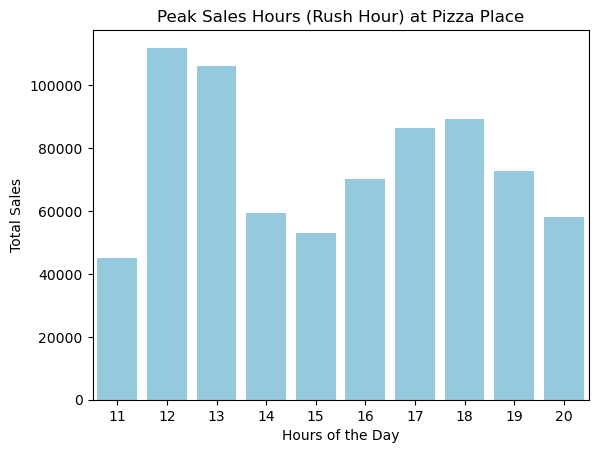

In [53]:
sns.barplot(top_hours, x='hours', y='total_sales', color='skyblue')
plt.title('Peak Sales Hours (Rush Hour) at Pizza Place')
plt.xlabel('Hours of the Day')
plt.ylabel('Total Sales')

plt.show()

We see that between 12:00pm and 01:00pm sales hit an all time high. Dips again but rises toward 5:00pm and 6:00pm which most likely are lunch breaks and close of work

#### Daily Sales

In [54]:
#extracting day name from datetime column
df['day_name'] = df['date_time'].dt.day_name()

In [55]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date_time,pizza_type_id,name,category,ingredients,size,price,sales,hours,day_name
0,1,1,hawaiian_m,1,2015-01-01 11:38:36,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25,13.25,11,Thursday
1,2,2,classic_dlx_m,1,2015-01-01 11:57:40,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00,16.00,11,Thursday
2,3,2,five_cheese_l,1,2015-01-01 11:57:40,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50,18.50,11,Thursday
3,4,2,ital_supr_l,1,2015-01-01 11:57:40,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",L,20.75,20.75,11,Thursday
4,5,2,mexicana_m,1,2015-01-01 11:57:40,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",M,16.00,16.00,11,Thursday


In [56]:
#group by day_name and aggregate sales
daily_sales = df.groupby('day_name')['sales'].sum().reset_index().sort_values(by='sales', ascending=False)

daily_sales

,day_name,sales
0,Friday,136073.90
4,Thursday,123528.50
2,Saturday,123182.40
6,Wednesday,114408.40
5,Tuesday,114133.80
1,Monday,107329.55
3,Sunday,99203.50


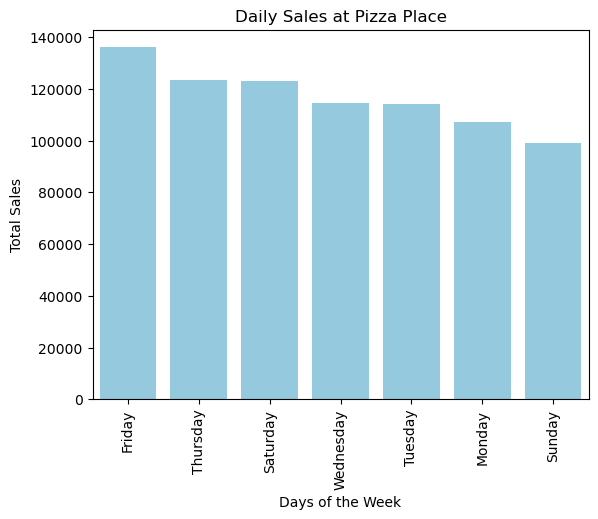

In [116]:
sns.barplot(daily_sales, x= 'day_name', y='sales', color='skyblue')
plt.title('Daily Sales at Pizza Place')
plt.ylabel('Total Sales')
plt.xlabel('Days of the Week')
plt.xticks(rotation=90)

plt.show()

Fridays record the highest sales. TGIF celebrations

#### Monthly Sales

In [65]:
#define the calendar order of the months so it doesn't group by in alphabetical order
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

In [63]:
#extracting month name
df['month_name'] = df['date_time'].dt.month_name()

In [66]:
#converting the month_name to a categorical datatype and include the order
df['month_name'] = pd.Categorical(df['month_name'], categories= month_order, ordered = True)

In [68]:
monthly_sales = df.groupby('month_name')['sales'].sum().reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_7824\3259359456.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('month_name')['sales'].sum().reset_index()


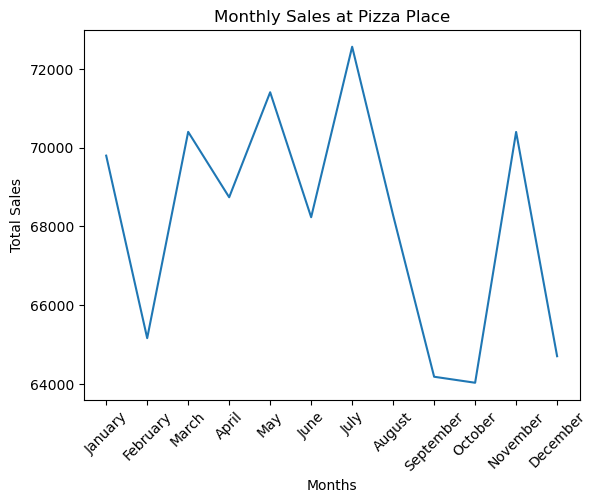

In [73]:
sns.lineplot(monthly_sales, x= 'month_name', y='sales')
plt.title('Monthly Sales at Pizza Place')
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.xticks(rotation= 45)

plt.show()

We notice a sharp increase in sales towards July and then a sharp dip in sales throughout August to October before rising in Novemeber and falling again in December

#### Pizza Type Performance

For this metrics we will be looking at the total quantity ordered for each pizza type to determine which ones aren't doing well on the menu

In [74]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date_time,pizza_type_id,name,category,ingredients,size,price,sales,hours,day_name,month_name
0,1,1,hawaiian_m,1,2015-01-01 11:38:36,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25,13.25,11,Thursday,January
1,2,2,classic_dlx_m,1,2015-01-01 11:57:40,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00,16.00,11,Thursday,January
2,3,2,five_cheese_l,1,2015-01-01 11:57:40,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50,18.50,11,Thursday,January
3,4,2,ital_supr_l,1,2015-01-01 11:57:40,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",L,20.75,20.75,11,Thursday,January
4,5,2,mexicana_m,1,2015-01-01 11:57:40,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",M,16.00,16.00,11,Thursday,January


In [77]:
pizza_perf = df.groupby('pizza_type_id')['quantity'].sum().reset_index().sort_values(by='quantity')

pizza_perf

,pizza_type_id,quantity
2,brie_carre,490
15,mediterraneo,934
3,calabrese,937
28,spinach_supr,950
23,soppressata,961
26,spin_pesto,970
6,ckn_pesto,973
14,ital_veggie,981
5,ckn_alfredo,987
10,green_garden,997


In [80]:
pizza_perf.rename(columns={'pizza_type_id': 'pizza_type', 'quantity': 'total_orders'}, inplace=True)

In [81]:
low_perf_pizza = pizza_perf.head(10)

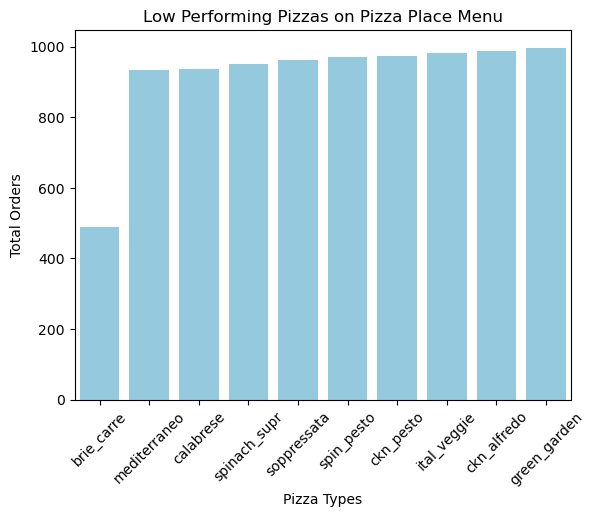

In [117]:
sns.barplot(low_perf_pizza, x ='pizza_type', y='total_orders', color='skyblue')
plt.xticks(rotation=45)
plt.title('Low Performing Pizzas on Pizza Place Menu')
plt.ylabel('Total Orders')
plt.xlabel('Pizza Types')

plt.show()

Brie Carre Pizza seems to be the least ordered pizza with less than 500 orders

#### Size, Price and Order Relationship

Does the size and price affect the sales and orders?

In [89]:
df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date_time',
       'pizza_type_id', 'name', 'category', 'ingredients', 'size', 'price',
       'sales', 'hours', 'day_name', 'month_name'],
      dtype='object')

In [104]:
size_rel = df.groupby('size').agg({'price': 'mean', 'quantity': 'sum'}).reset_index()

In [106]:
size_rel.rename(columns={'size':'pizza_size', 'price':'avg_price', 'quantity':'total_orders'}, inplace=True)

In [107]:
size_rel

,pizza_size,avg_price,total_orders
0,L,19.802553,18956
1,M,15.951219,15635
2,S,12.364328,14403
3,XL,25.500000,552
4,XXL,35.950000,28


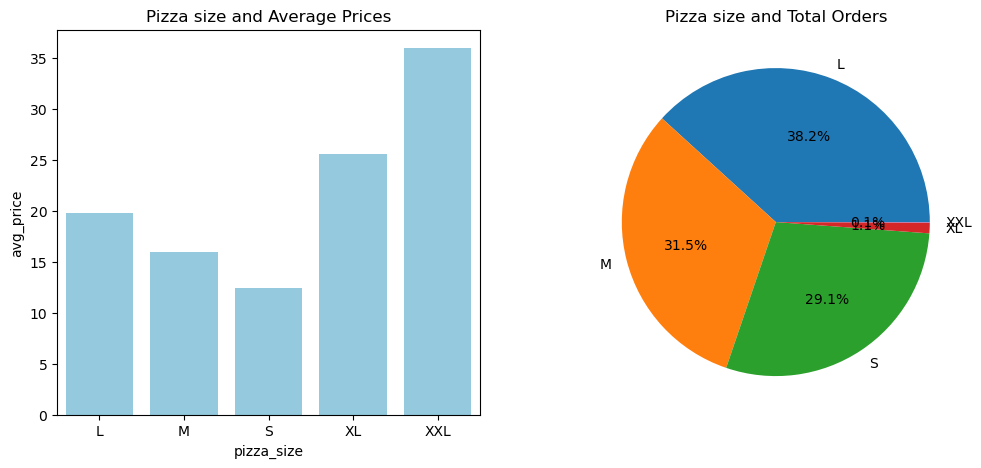

In [115]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(size_rel, x= 'pizza_size', y = 'avg_price', color = 'skyblue', ax=ax[0])
ax[0].set_title('Pizza size and Average Prices')

ax[1].pie(size_rel['total_orders'],
        labels = size_rel['pizza_size'],
        autopct='%1.1f%%')
ax[1].set_title('Pizza size and Total Orders')

plt.show()

From the charts we see that XXL pizzas are more expensive but don't get much orders, small size pizzas have the least price and yet make up 29.1% of orders. Large sized pizzas have the largest order quantity.